# Marine Mammals Classifier Dataset Visualizations

## Load libraries

First of all, we need to load the libraries that we will use in this notebook.

Main uses we will give to these libraries are data manipulation, data visualization, audio processing and deep learning model training. Also, to improve model analysis,  we will use libraries to log and save model training and evaluation.

In [49]:
# Monitorization
import comet_ml
from comet_ml import start
from comet_ml import ExperimentConfig
from private_credentials import API_COMETML

import os

# Data
import numpy as np
import pandas as pd

# Audio
import librosa
import librosa.display
from pydub import AudioSegment

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Performance Metrics and Model Selection
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, CSVLogger, ReduceLROnPlateau
from sklearn.utils import shuffle
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import classification_report

# Deep Learning Visualization
from sklearn.metrics import confusion_matrix

In [50]:
SEED = 42

## Preprocess Audios

First of all, we need to preprocess the audios. We have the audios in folders in different sampling rate. And might have different durations. We need to preprocess them to have the same duration and sampling rate.

We will use BirdNET as a pre-trained model to classify the audios. BirdNET is a deep learning model that classifies bird sounds. We will use it to classify marine mammals sounds. In recent research it has been demonstrated that [global birdsong embeddings enable superior transfer learning for bioacoustic classification](https://www.nature.com/articles/s41598-023-49989-z). BirdNET and Perch are the best performance models for all the datasets used in the research. For this reasen we will focus on one of those models, BirdNET.

BirdNET takes 3 second windwos as input as most calls and songs of different species are 3 seconds. This is the target duration we will use for the audios.

Our target data sampling rate was 256000 Hz but BirdNET takes 48000 Hz, so 48000 Hz will be used. It just changes the resolution of the audio. Also, some audios from Watkins Marine Mammals are undersampled (500-1000 Hz) making it complete silence above those frequencies which is not the case in the original audio.

I found out that upsampling those audios to 48000 Hz works better than keeping them at their original sampling rate. So all the audios will be resampled to 48000 Hz.

In [51]:
# Function to preprocess audio
def preprocess_audio(file_path, target_sr=48000, duration=3, min_duration = 1, df_background=None, fill_mode='silence'):
    fill_modes = ['silence', 'background', 'repeat', 'noise', 'random']
    # Ensure fill_silence_mode is valid (either 'silence', 'background', 'repeat' or 'random') if not print and set to 'silence'
    if fill_mode not in fill_modes:
        print(f"Invalid fill_silence_mode: {fill_mode}. Setting to 'silence'. Valid options are {fill_modes}.")
        fill_mode = 'silence'
        # If fill_mode is 'background' and no background data is provided, set to 'silence'
        if fill_mode == 'background' and df_background is None:
            print(f"No background data provided. Setting fill_mode to 'silence'.")
            fill_mode = 'silence'
    
    # Load audio
    signal, _ = librosa.load(file_path, sr=target_sr, mono=True)
    # resample to target_sr
    # signal = librosa.resample(signal, orig_sr=sr, target_sr=target_sr)
    
    # Calculate the maximum length in samples and min length in samples
    max_length = target_sr * duration  # e.g., 48000 * 3
    min_length = target_sr * min_duration  # e.g., 48000 * 1
    
    # If the signal is shorter than the desired max length, fill with the selected option
    if len(signal) < max_length:

        if fill_mode == "random":
            fill_mode = np.random.choice(['silence', 'background', 'repeat', 'noise'])
        elif fill_mode == "silence":
            padding = max_length - len(signal)
            pad_left = padding // 2
            pad_right = padding - pad_left
            signal = np.pad(signal, (pad_left, pad_right), mode='constant')
        elif fill_mode == "background":
            # Randomly select a background audio file
            # take one random background file
            background_file = df_background.sample(SEED)["File"].values[0]
            background_signal, _ = librosa.load(background_file, sr=target_sr, mono=True)
            # resample to target_sr
            # background_signal = librosa.resample(background_signal, orig_sr=sr, target_sr=target_sr)
            background_signal = background_signal[:max_length]
            # Fill silence in time with background signal
            padding = max_length - len(signal)
            pad_left = padding // 2
            pad_right = padding - pad_left
            # signal = background + signal + background
            signal = np.pad(signal, (pad_left, pad_right), mode='constant')
            # signal[signal <= 0.0] = background_signal[signal <= 0.0]
            signal = signal*0.3 + background_signal*0.7
        elif fill_mode == "repeat":
            repeats = max_length // len(signal)
            remainder = max_length % len(signal)
            signal = np.concatenate([signal] * repeats + [signal[:remainder]])
        elif fill_mode == "noise":
            noise = np.random.normal(0, 0.01, len(signal))
            # Fill only where it is silence
            signal = signal + noise

        return signal
    
    # If the signal is longer than the desired length, split into 3-second windows
    elif len(signal) > max_length:
        segments = []

        # take first 3 seconds
        segments.append(signal[:max_length])

        # take middle 3 seconds
        mid_start = len(signal) // 2 - max_length // 2
        segments.append(signal[mid_start:mid_start + max_length])

        # take last 3 seconds
        segments.append(signal[-max_length:])

        signal = segments[1]

        # return middle segment
        return signal
    
    # If the signal is exactly the desired length, return as is
    else:
        _, orig_sr = librosa.load(file_path, mono=True)
        # if signal sr is not target_sr, fill with background
        # if orig_sr != target_sr:
        #     background_file = df_background.sample()["File"].values[0]
        #     background_signal, _ = librosa.load(background_file, sr=target_sr, mono=True)
        #     background_signal = background_signal[:max_length]
        #     signal = signal*0.9 + background_signal*0.1

        return signal

In [52]:
import pandas as pd
# load watkins data
df_watkins = pd.read_csv('../../Dataset/CSVs/Datasets/WatkinsMarineMammalsSegmented.csv')
df_background = pd.read_csv('../../Dataset/CSVs/Datasets/SEANIMALMOVEBackgroundSegmented.csv')
df_elenapapale = pd.read_csv("../../Dataset/CSVs/Datasets/ElenaPapaleFinfinbackWhaleSegmented.csv")

In [53]:
# rename column SegmentedFile to File
df_watkins = df_watkins.rename(columns={"SegmentPath": "File"})
df_background = df_background.rename(columns={"SegmentPath": "File"})
df_elenapapale = df_elenapapale.rename(columns={"SegmentPath": "File"})

CommonDolphin


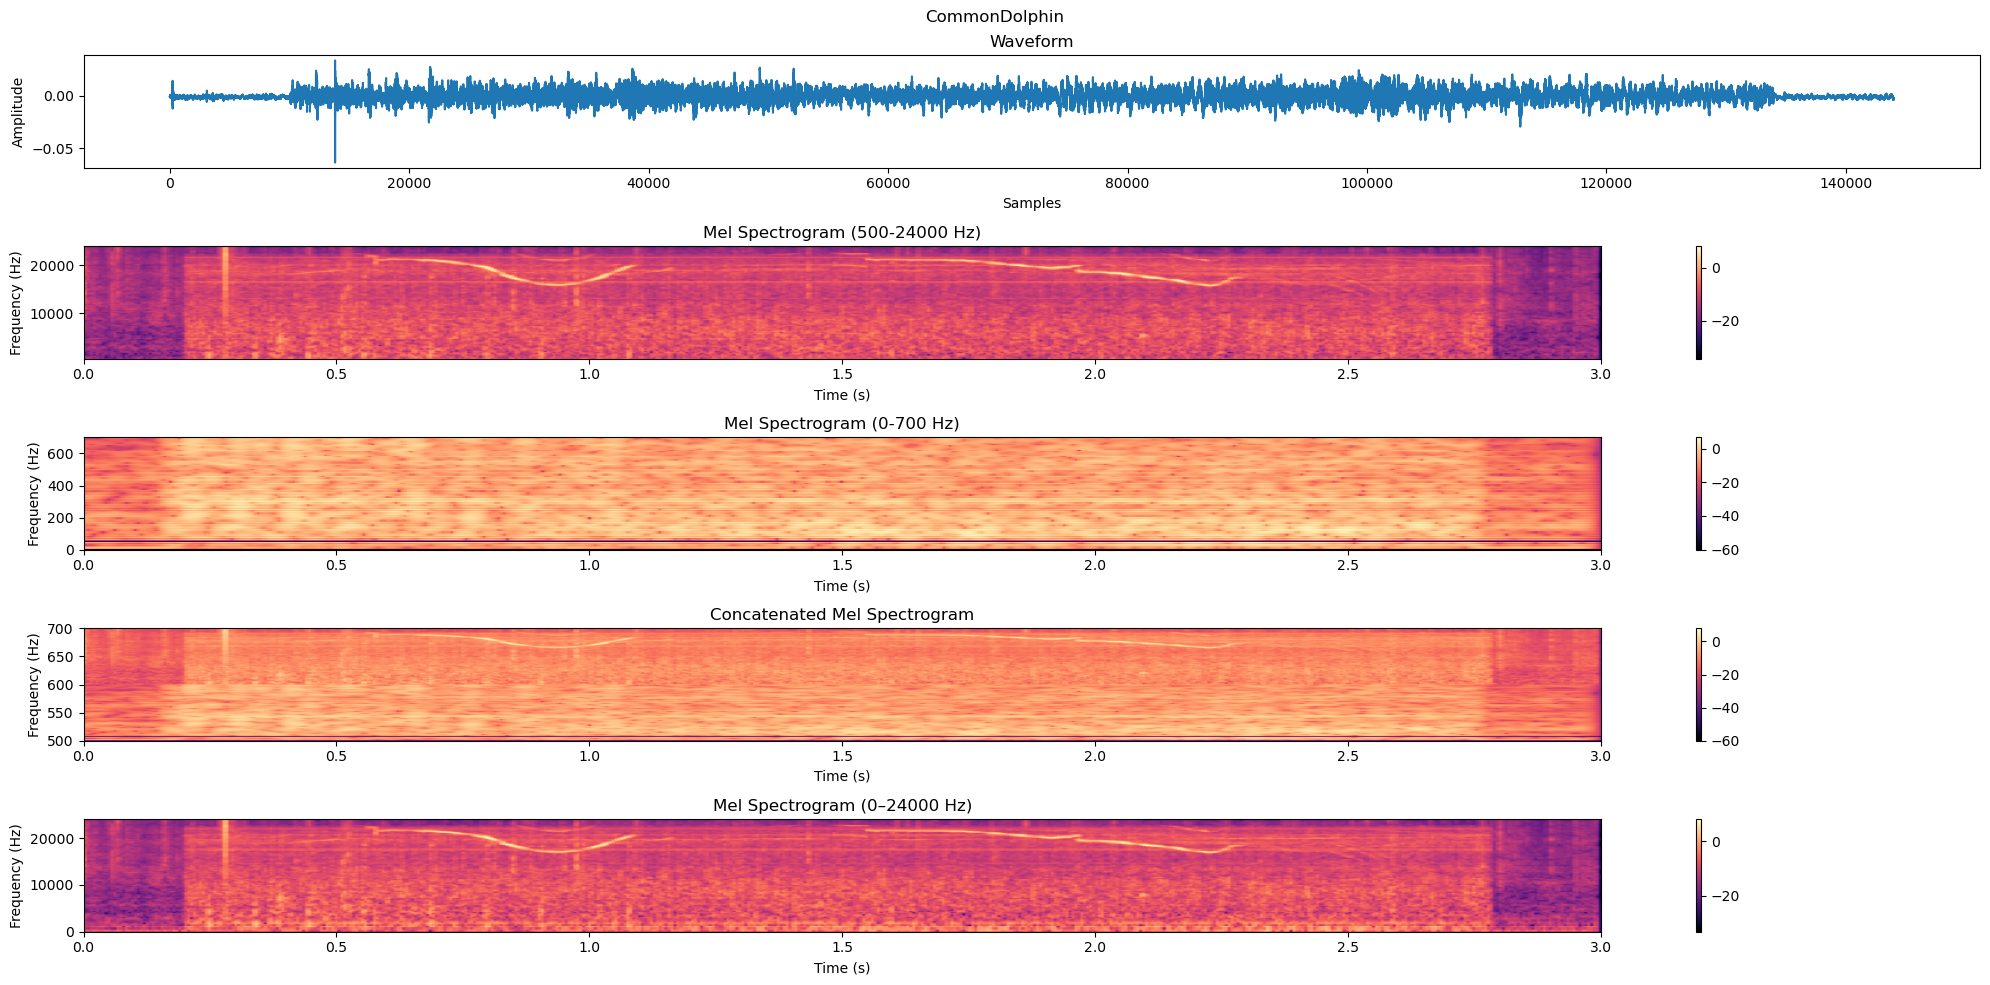

In [54]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

# TODO: Fix the Y-axis values to match mel scale

# Test preprocess on a single file
target_sr = 48000

class_interest = "CommonDolphin"

sample_file = df_watkins[df_watkins["Class"] == class_interest]["File"].values[1]
# class_interest = df_watkins[df_watkins["File"] == sample_file]["Class"].values[0]
processed_audio = preprocess_audio(
    sample_file, target_sr=target_sr, duration=3, fill_mode='background', df_background=df_background
)

# Print class
print(df_watkins[df_watkins["File"] == sample_file]["Class"].values[0])

# TensorFlow-based Mel spectrogram settings
spec_shape = (96, 511)

frame_length = 1024
frame_step = 280
frame_length_low = 4096 # 2048 # 8192 #4096 # 8192
frame_step_low = 278

hf_fmin = 500 # 500
hf_fmax = 24000 # 24000
lf_fmin = 0
lf_fmax = 700 # 700

# Generate STFT
stft = tf.signal.stft(
    processed_audio,
    frame_length=frame_length,
    frame_step=frame_step,
    fft_length=frame_length,
    pad_end=True
)

stft_low = tf.signal.stft(
    processed_audio,
    frame_length=frame_length_low,
    frame_step=frame_step_low,
    fft_length=frame_length_low,
    pad_end=True
)

# Compute magnitude
spectrogram = tf.abs(stft)
spectrogram_low = tf.abs(stft_low)

# Create Mel filter bank
mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=spec_shape[0],
    num_spectrogram_bins=frame_length // 2 + 1,
    sample_rate=target_sr,
    lower_edge_hertz=hf_fmin,
    upper_edge_hertz=hf_fmax,
    dtype=tf.float32
)

# Apply Mel filter bank
mel_spectrogram = tf.tensordot(spectrogram, mel_filterbank, axes=1)

mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(mel_filterbank.shape[-1:]))

# Convert to dB scale
mel_spectrogram_db = 10.0 * tf.math.log(mel_spectrogram + 1e-6) / tf.math.log(10.0)

# Plot the results
fig, ax = plt.subplots(5, 1, figsize=(20, 10))

# add class as title of the whole plot not ax0 or ax1
fig.suptitle(class_interest)

# Waveform
ax[0].plot(processed_audio)
ax[0].set_title("Waveform")
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Amplitude")

# High Frequency Mel Spectrogram
im1 = ax[1].imshow(
    mel_spectrogram_db.numpy().T,
    origin="lower",
    aspect="auto",
    extent=[0, len(processed_audio) / target_sr, hf_fmin, hf_fmax],
    cmap="magma"
)
ax[1].set_title(f"Mel Spectrogram ({hf_fmin}-{hf_fmax} Hz)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Frequency (Hz)")
fig.colorbar(im1, ax=ax[1])

# Low Frequency Mel Spectrogram

mel_filterbank_low = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=spec_shape[0],
    num_spectrogram_bins=frame_length_low // 2 + 1,
    sample_rate=target_sr,
    lower_edge_hertz=lf_fmin,
    upper_edge_hertz=lf_fmax,
    dtype=tf.float32
)


mel_spectrogram_low = tf.tensordot(spectrogram_low, mel_filterbank_low, axes=1)
mel_spectrogram_low.set_shape(spectrogram_low.shape[:-1].concatenate(mel_filterbank_low.shape[-1:]))
mel_spectrogram_db_low = 10.0 * tf.math.log(mel_spectrogram_low + 1e-6) / tf.math.log(10.0)

im2 = ax[2].imshow(
    mel_spectrogram_db_low.numpy().T,
    origin="lower",
    aspect="auto",
    extent=[0, len(processed_audio) / target_sr, lf_fmin, lf_fmax],
    cmap="magma"
)
ax[2].set_title(f"Mel Spectrogram ({lf_fmin}-{lf_fmax} Hz)")
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Frequency (Hz)")
fig.colorbar(im2, ax=ax[2])

# concat both mel spectrograms

# # Ensure the same time resolution for both spectrograms
# time_resolution_hf = mel_spectrogram_db.shape[0]
# time_resolution_lf = mel_spectrogram_db_low.shape[0]

# if time_resolution_hf != time_resolution_lf:
#     # Resample the low-frequency spectrogram to match the high-frequency spectrogram
#     mel_spectrogram_db_low_resampled = tf.image.resize(
#         mel_spectrogram_db_low[..., tf.newaxis],  # Add channel dimension for resizing
#         size=[time_resolution_hf, mel_spectrogram_db_low.shape[1]],
#         method="bilinear"
#     )[..., 0]  # Remove channel dimension after resizing
# else:
#     mel_spectrogram_db_low_resampled = mel_spectrogram_db_low

# # Add channel dimensions to both spectrograms
# mel_spectrogram_db_resampled = mel_spectrogram_db[..., tf.newaxis]
# mel_spectrogram_db_low_resampled = mel_spectrogram_db_low_resampled[..., tf.newaxis]

# # Concatenate along the channel axis
# concatenated_spectrogram = tf.concat([mel_spectrogram_db_resampled, mel_spectrogram_db_low_resampled], axis=-1)

# Ensure the same time resolution for both spectrograms
time_resolution_hf = mel_spectrogram_db.shape[0]
time_resolution_lf = mel_spectrogram_db_low.shape[0]

if time_resolution_hf != time_resolution_lf:
    # Resample the low-frequency spectrogram to match the high-frequency spectrogram
    mel_spectrogram_db_low_resampled = tf.image.resize(
        mel_spectrogram_db_low[..., tf.newaxis],  # Add channel dimension for resizing
        size=[time_resolution_hf, mel_spectrogram_db_low.shape[1]],
        method="bilinear"
    )[..., 0]  # Remove channel dimension after resizing
else:
    mel_spectrogram_db_low_resampled = mel_spectrogram_db_low

# Concatenate both mel spectrograms
concatenated_spectrogram = tf.concat([mel_spectrogram_db_low_resampled, mel_spectrogram_db], axis=-1)

# Plot concatenated Mel spectrogram
im3 = ax[3].imshow(
    concatenated_spectrogram.numpy().T,
    origin="lower",
    aspect="auto",
    extent=[0, len(processed_audio) / target_sr, hf_fmin, lf_fmax],
    cmap="magma"
)
ax[3].set_title(f"Concatenated Mel Spectrogram")
ax[3].set_xlabel("Time (s)")
ax[3].set_ylabel("Frequency (Hz)")
fig.colorbar(im3, ax=ax[3])


# Full Mel Spectrogram
fmin = 0
fmax = 24000 # target_sr // 2
mel_filterbank_full = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=spec_shape[0],
    num_spectrogram_bins=frame_length // 2 + 1,
    sample_rate=target_sr,
    lower_edge_hertz=fmin,
    upper_edge_hertz=fmax,
    dtype=tf.float32
)
mel_spectrogram_full = tf.tensordot(spectrogram, mel_filterbank_full, axes=1)
mel_spectrogram_full.set_shape(spectrogram.shape[:-1].concatenate(mel_filterbank_full.shape[-1:]))
mel_spectrogram_db_full = 10.0 * tf.math.log(mel_spectrogram_full + 1e-6) / tf.math.log(10.0)

im2 = ax[4].imshow(
    mel_spectrogram_db_full.numpy().T,
    origin="lower",
    aspect="auto",
    extent=[0, len(processed_audio) / target_sr, fmin, fmax],
    cmap="magma"
)
ax[4].set_title(f"Mel Spectrogram (0–{fmax} Hz)")
ax[4].set_xlabel("Time (s)")
ax[4].set_ylabel("Frequency (Hz)")
fig.colorbar(im2, ax=ax[4])

plt.tight_layout()
plt.show()

# Listen to audio
ipd.Audio(processed_audio, rate=target_sr)

In [55]:
# import random

# # Number of samples per class
# num_samples_per_class = 7

# df = df_watkins

# # Classes and their files
# classes = df["Class"].unique()

# # Set up the figure
# fig, axes = plt.subplots(
#     len(classes), num_samples_per_class,
#     figsize=(50, 2 * len(classes)),
#     gridspec_kw={'hspace': 0.6, 'wspace': 0.4}
# )

# # Iterate over each class
# for i, class_name in enumerate(classes):
#     # Randomly select samples for the current class
#     class_files = df[df["Class"] == class_name]["File"].values
#     selected_files = random.sample(list(class_files), num_samples_per_class)
    
#     # Process each file
#     for j, sample_file in enumerate(selected_files):
#         # Preprocess the audio
#         processed_audio = preprocess_audio(
#             sample_file,
#             target_sr=target_sr,
#             duration=3,
#             fill_mode='background',
#             df_background=df_background
#         )
        
#         # Compute concatenated Mel spectrogram
#         # (Same steps as in your single-sample code)
#         stft = tf.signal.stft(
#             processed_audio,
#             frame_length=frame_length,
#             frame_step=frame_step,
#             fft_length=frame_length,
#             pad_end=True
#         )
#         stft_low = tf.signal.stft(
#             processed_audio,
#             frame_length=frame_length_low,
#             frame_step=frame_step_low,
#             fft_length=frame_length_low,
#             pad_end=True
#         )
#         spectrogram = tf.abs(stft)
#         spectrogram_low = tf.abs(stft_low)
        
#         mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
#             num_mel_bins=spec_shape[0],
#             num_spectrogram_bins=frame_length // 2 + 1,
#             sample_rate=target_sr,
#             lower_edge_hertz=hf_fmin,
#             upper_edge_hertz=hf_fmax,
#             dtype=tf.float32
#         )
#         mel_filterbank_low = tf.signal.linear_to_mel_weight_matrix(
#             num_mel_bins=spec_shape[0],
#             num_spectrogram_bins=frame_length_low // 2 + 1,
#             sample_rate=target_sr,
#             lower_edge_hertz=lf_fmin,
#             upper_edge_hertz=lf_fmax,
#             dtype=tf.float32
#         )
        
#         mel_spectrogram = tf.tensordot(spectrogram, mel_filterbank, axes=1)
#         mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(mel_filterbank.shape[-1:]))
#         mel_spectrogram_low = tf.tensordot(spectrogram_low, mel_filterbank_low, axes=1)
#         mel_spectrogram_low.set_shape(spectrogram_low.shape[:-1].concatenate(mel_filterbank_low.shape[-1:]))
        
#         mel_spectrogram_db = 10.0 * tf.math.log(mel_spectrogram + 1e-6) / tf.math.log(10.0)
#         mel_spectrogram_db_low = 10.0 * tf.math.log(mel_spectrogram_low + 1e-6) / tf.math.log(10.0)
        
#         time_resolution_hf = mel_spectrogram_db.shape[0]
#         time_resolution_lf = mel_spectrogram_db_low.shape[0]
        
#         if time_resolution_hf != time_resolution_lf:
#             mel_spectrogram_db_low = tf.image.resize(
#                 mel_spectrogram_db_low[..., tf.newaxis],
#                 size=[time_resolution_hf, mel_spectrogram_db_low.shape[1]],
#                 method="bilinear"
#             )[..., 0]
        
#         concatenated_spectrogram = tf.concat(
#             [mel_spectrogram_db_low, mel_spectrogram_db], axis=-1
#         )
        
#         # Plot the concatenated spectrogram
#         ax = axes[i, j]
#         im = ax.imshow(
#             concatenated_spectrogram.numpy().T,
#             origin="lower",
#             aspect="auto",
#             cmap="magma"
#         )
#         origin_class = df[df["File"] == sample_file]["Origin"].values[0]
#         ax.set_title(f"{class_name} - {origin_class}", fontsize=8)
#         ax.set_xlabel("Time (s)", fontsize=6)
#         ax.set_ylabel("Freq. (Hz)", fontsize=6)
#         ax.tick_params(axis='both', which='major', labelsize=6)
#         fig.colorbar(im, ax=ax, shrink=0.5)
        
# # Set figure title and layout
# plt.suptitle("Concatenated Mel Spectrograms per Class", fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.97])

# # Save the figure as pdf
# plt.savefig("concatenated_mel_spectrograms.pdf")

# plt.show()

In [56]:
# # take 25 random samples of different classes and plot in a grid with its class
# # Select 25 random samples
# random_samples = df_train.sample(25, random_state=42)

# # Create a grid of plots
# fig, axes = plt.subplots(5, 5, figsize=(20, 20))

# # Flatten the axes
# axes = axes.ravel()

# # Loop through all the samples

# for i, (_, row) in enumerate(random_samples.iterrows()):
#     # Load the audio file
#     signal, sr = librosa.load(row['File'], sr=48000)

#     # preprocess the audio
#     processed_audios = preprocess_audio(row['File'], target_sr=48000, duration=3)
    
#     # Calculate the mel spectrogram
#     mel_spectrogram = librosa.feature.melspectrogram(y=processed_audios[0], sr=48000)
#     mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
#     # Plot the mel spectrogram
#     axes[i].imshow(mel_spectrogram, origin='lower')
#     axes[i].set_title(f"{row['Class']} ({classes_mapping[row['Class']]})")
#     axes[i].axis('off')

# plt.tight_layout()
# plt.show()

# Data Generators

## Data Augmentation

In [57]:
import librosa
import matplotlib.pyplot as plt

def add_noise(signal, noise_factor=0.005):
    noise = np.random.randn(signal.shape[0])
    augmented_signal = signal + noise_factor * noise
    return augmented_signal

def shift_time(signal, shift_max=0.9):
    shift = np.random.randint(int(shift_max * len(signal)))
    augmented_signal = np.roll(signal, shift)
    return augmented_signal

# Mix Up
def mix_up(signal1, signal2, alpha=0.5):
    mixed_signal = alpha * signal1 + (1 - alpha) * signal2
    return mixed_signal

# Check data augmentation in the same audio, plot the original and the augmented audio with each of the changes
# Load the audio file
# sample_file = df_train['File'][0]
# sample_file_1 = df_train['File'][1]
# signal, sr = librosa.load(sample_file, sr=48000)
# signal_1, sr_1 = librosa.load(sample_file_1, sr=48000)

# # preprocess the audio
# signal = preprocess_audio(sample_file, target_sr=48000, duration=3)
# signal_1 = preprocess_audio(sample_file_1, target_sr=48000, duration=3)

# # Add noise
# augmented_signal_noise = add_noise(signal, noise_factor=0.005)

# # Shift time
# augmented_signal_shift = shift_time(signal, shift_max=0.2)

# # Mix up
# augmented_signal_mix_up = mix_up(signal, signal_1, alpha=0.5)

# # Mel spectrograms
# mel_spectrogram = librosa.feature.melspectrogram(y=signal, sr=48000)
# mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

# mel_spectrogram_noise = librosa.feature.melspectrogram(y=augmented_signal_noise, sr=48000)
# mel_spectrogram_noise = librosa.power_to_db(mel_spectrogram_noise, ref=np.max)

# mel_spectrogram_shift = librosa.feature.melspectrogram(y=augmented_signal_shift, sr=48000)
# mel_spectrogram_shift = librosa.power_to_db(mel_spectrogram_shift, ref=np.max)

# mel_spectrogram_mix_up = librosa.feature.melspectrogram(y=augmented_signal_mix_up, sr=48000)
# mel_spectrogram_mix_up = librosa.power_to_db(mel_spectrogram_mix_up, ref=np.max)

# # Visualize mel spectrogram
# plt.figure(figsize=(40, 8))
# plt.subplot(1, 4, 1)
# librosa.display.specshow(mel_spectrogram, sr=48000, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
# plt.title(f'Original ({df_train["Class"][0]})', fontsize=20)
# plt.tight_layout()

# plt.subplot(1, 4, 2)
# librosa.display.specshow(mel_spectrogram_noise, sr=48000, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
# plt.title('Noise', fontsize=20)
# plt.tight_layout()

# plt.subplot(1, 4, 3)
# librosa.display.specshow(mel_spectrogram_shift, sr=48000, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
# plt.title('Shift', fontsize=20)
# plt.tight_layout()

# plt.subplot(1, 4, 4)
# librosa.display.specshow(mel_spectrogram_mix_up, sr=48000, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
# plt.title(f'Mix Up with {df_train["Class"][1]}', fontsize=20)
# plt.tight_layout()

In [58]:
def audio_data_generator(df, classes_list, classes_mapping, batch_size=32, target_sr=48000, duration=3, augment=False, df_background=[]):
    while True:
        X, y = [], []
        # shuffle the dataframe
        df = shuffle(df)
        # reset index
        df = df.reset_index(drop=True)
        for _, row in df.iterrows():
            file_path = row['File']
            cls_index = classes_mapping[row['Class']] # Ensure it is the same classes mapping
            signal = preprocess_audio(file_path, target_sr, duration)
            # print(f"File: {file_path}, Class: {row['Class']}, Signals: {len(signals)}")
            if augment:
                if np.random.rand() < 0.5:
                    signal = add_noise(signal)
                if np.random.rand() < 0.5:
                    signal = shift_time(signal)
                if np.random.rand() < 0.5:
                    # If background noise is provided
                    if len(df_background) > 0:
                        # random background noise
                        random_noise = df_background['File'][np.random.randint(0, len(df_background))]
                        signal_1 = preprocess_audio(random_noise, target_sr=48000, duration=3)
                        # signal_1 = noise_signals[np.random.randint(0, len(noise_signals))]
                        signal = mix_up(signal, signal_1, alpha=np.random.uniform(0, 0.7))
                    else:
                        signal_1 = preprocess_audio(df['File'][np.random.randint(0, len(df))], target_sr=48000, duration=3)
                        signal = mix_up(signal, signal_1, alpha=0.5)
            
            X.append(signal)
            y.append(cls_index)
            
            if len(X) == batch_size:
                X = np.array(X)
                y = np.array(y)
                X, y = shuffle(X, y)
                y = to_categorical(y, num_classes=len(classes_list))
                # print(f"Batch X shape: {X.shape}, y shape: {y.shape}")
                yield X, y
                X, y = [], []

def audio_data_generator_test(df, classes_list, classes_mapping, batch_size=32, target_sr=48000, duration=3):
    while True:
        XPath, XSignal, y = [], [], []
        for _, row in df.iterrows():
            file_path = row['File']
            cls_index = classes_mapping[row['Class']]
            signal = preprocess_audio(file_path, target_sr, duration)
            XPath.append(file_path)
            # X_segment.append(i)
            XSignal.append(signal)
            y.append(cls_index)
            
            if len(XSignal) == batch_size:
                XSignal = np.array(XSignal)
                y = np.array(y)
                yield XPath, XSignal, to_categorical(y, num_classes=len(classes_list))
                XPath, XSignal, y = [], [], []

# Test the generator with test_Df
# test_gen = audio_data_generator(df_test, CLASSES, CLASSES_MAPPING, batch_size=8, target_sr=48000, duration=3)
# X, y = next(test_gen)
# print(X.shape, y.shape)

In [59]:
# # take 25 random samples of different classes and plot in a grid with its class
# # Select 25 random samples
# random_samples = df_test.sample(25, random_state=42)

# # Create a grid of plots
# fig, axes = plt.subplots(5, 5, figsize=(20, 20))

# # Flatten the axes
# axes = axes.ravel()

# # Loop through all the samples

# for i, (_, row) in enumerate(random_samples.iterrows()):
#     # Load the audio file
#     signal, sr = librosa.load(row['File'], sr=48000)

#     # preprocess the audio
#     processed_audios = preprocess_audio(row['File'], target_sr=48000, duration=3)
    
#     # Calculate the mel spectrogram
#     mel_spectrogram = librosa.feature.melspectrogram(y=processed_audios[0], sr=48000)
#     mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
#     # Plot the mel spectrogram
#     axes[i].imshow(mel_spectrogram, origin='lower')
#     axes[i].set_title(f"{row['Class']} ({classes_mapping[row['Class']]})")
#     axes[i].axis('off')

# plt.tight_layout()
# plt.title('Test Data with Data Augmentation')
# plt.show()

# Model Functions

In [60]:
import warnings
warnings.filterwarnings('ignore')

def load_base_model(model_path = 'BirdNET-Analyzer-V2.4/V2.4/BirdNET_GLOBAL_6K_V2.4_Model/', freeze = True, n_freeze = 4, classes=[]):
    model = tf.keras.models.load_model(model_path, compile=False).model

    # Get the output of the second to last layer
    output_layer = model.layers[-2].output

    # Add 3 dense layers: 512, 128 and len(classes)

    # Add a dense layer with 512 units and ReLU activation
    x = tf.keras.layers.Dense(256, activation='relu')(output_layer)

    # Add a dense layer with 128 units and ReLU activation
    x = tf.keras.layers.Dense(64, activation='relu')(x)

    # Add a dense layer with the number of classes and softmax activation
    output_layer = tf.keras.layers.Dense(len(classes), activation='softmax')(x)

    # output_layer = tf.keras.layers.Dense(len(classes), activation='softmax')(model.output)

    # Create a new model
    model = tf.keras.models.Model(inputs=model.input, outputs=output_layer)

    # Compile
    # model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'AUC', 'Precision', 'Recall', 'Sensitivity', 'TruePositives', 'TrueNegatives', 'FalsePositives', 'FalseNegatives', 'CategoricalAccuracy', 'F1Score'])

    if freeze:
        # Freeze first layers
        for layer in model.layers[:-n_freeze]:
            layer.trainable = False

    print(model.summary())

    return model

def model_compile(model, optimizer = "adam", loss = "categorical_crossentropy", metrics = ['accuracy']):
    # Compile
    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=metrics,
        ) 
    
    return model

def train_model(model, df_train, df_val, classes, classes_mapping, batch_size=8, target_sr=48000, duration=3, epochs=100, callbacks=None, doshuffle=True, doDataAugmentation=False, df_background=[]):
    # Training and Validation Generators

    # shuffle data
    if doshuffle:
        df_train = shuffle(df_train, random_state=42)
        df_val = shuffle(df_val, random_state=42)

    train_gen = audio_data_generator(df_train, classes, classes_mapping, batch_size=batch_size, target_sr=target_sr, duration=duration, augment=doDataAugmentation, df_background=df_background)
    val_gen = audio_data_generator(df_val, classes, classes_mapping, batch_size=batch_size, target_sr=target_sr, duration=duration)

    total_segments_train = df_train['Duration'].sum() // duration
    total_segments_val = df_val['Duration'].sum() // duration

    # Calculate steps per epoch and validation steps
    steps_per_epoch = total_segments_train // batch_size
    validation_steps = total_segments_val // batch_size

    # Train the model
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        shuffle=doshuffle,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return model, history

def plot_training_monitoring(history):
    # Plot accuracy and loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss")

    plt.show()

def evaluate_model(model, df_test, classes, classes_mapping, reverse_classes_mapping, batch_size=1, target_sr=48000, duration=3, plot_confusion_matrix=True):
    # Evaluate on test data
    # calculate total segments of 3 seconds in df_Test (summatory of Duration of each file) / 3
    test_gen = audio_data_generator(df_test, classes, classes_mapping, batch_size=batch_size)

    total_segments = len(df_test)

    test_steps = total_segments // batch_size

    results = model.evaluate(test_gen, steps=test_steps)
    print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

    # predict all samples of df_test and get XPath, X_segment, XSignal, y_true and y_predicted
    test_gen = audio_data_generator_test(df_test, classes, classes_mapping, batch_size=batch_size)
    y_true = []
    y_predicted = []
    XPath = []
    # X_segment = []
    XSignal = []

    for i in range(test_steps):
        XPath_batch, XSignal_batch, y_true_batch = next(test_gen)
        y_predicted_batch = model.predict(XSignal_batch, verbose=0)
        y_true.append(y_true_batch)
        y_predicted.append(y_predicted_batch)
        XPath.extend(XPath_batch)
        # X_segment.extend(X_segment_batch)
        XSignal.extend(XSignal_batch)

    y_true = np.vstack(y_true)
    y_predicted = np.vstack(y_predicted)

    # Get the predicted classes and confidence
    y_pred_classes = np.argmax(y_predicted, axis=1)
    y_pred_confidence = np.max(y_predicted, axis=1)

    y_pred = np.vstack((y_pred_classes, y_pred_confidence))
    y_true = np.argmax(y_true, axis=1)

    # Accuracy manual
    # accuracy_manual = np.mean(y_pred_classes == y_true)
    # print(f"Accuracy from model.evaluate: {results[1]}")
    # print(f"Manual accuracy: {accuracy_manual}")

    if plot_confusion_matrix:
        # Plot confusion matrix
        cm = confusion_matrix(y_true, y_pred_classes)
        plt.figure(figsize=(30, 30))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

        # Normalized by rows
        cm_normalized = cm / cm.sum(axis=1)[:, np.newaxis]
        plt.figure(figsize=(30, 30))
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title('Normalized Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

    # Put together X_eval, y_true, y_pred_classes, y_pred_confidence
    df_results = pd.DataFrame({
        'Path': list(XPath),
        # 'SegmentIdx': list(X_segment),
        'Signal': list(XSignal),
        'True': y_true,
        'Predicted': y_pred_classes,
        'PredictedClass': [reverse_classes_mapping[p] for p in y_pred_classes],
        'Confidence': y_pred_confidence
    })

    return df_results

# Experiment: Only Strait of Gibraltar Classes + BG ST Gibraltar + Data Augmentation

## Dataset

### Final Dataset

In [61]:
# Read dataset CSV
df = pd.read_csv("../../Dataset/CSVs/Datasets/Dataset.csv")
df["OriginalClass"] = df["Class"]

In [62]:
# Dont take Background or Cargo as classes
# df = df[~df['Class'].isin(['Background', 'Cargo'])]
# Make Cargo, Motor_boat and Ferry_FastFerry as Background
df.loc[df['Class'].isin(['Cargo', 'Motor_boat', 'Ferry_FastFerry', 'Human_diver']), 'Class'] = 'Background'

In [63]:
# dont take origin Neus Marine Mammals whose Class is KillerWhale
df = df[~((df['Origin'] == 'Neus Marine Mammals') & (df['Class'] == 'KillerWhale'))]
# From KillerWhale take 1000 longest files (Duration)
df_killerwhale = df[df['Class'] == 'KillerWhale'].sort_values(by='Duration', ascending=False).head(1300)
df = df[~(df['Class'] == 'KillerWhale')]
df = pd.concat([df, df_killerwhale])

In [64]:
# take classes and classes_mapping from df_wmm
CLASSES = df['Class'].unique()
CLASSES.sort()
# Add Background as first class
# CLASSES = np.insert(CLASSES, 0, 'Background')
CLASSES_MAPPING = {CLASSES[i]: i for i in range(len(CLASSES))}
REVERSE_CLASSES_MAPPING = {v: k for k, v in CLASSES_MAPPING.items()}
CLASSES, CLASSES_MAPPING, REVERSE_CLASSES_MAPPING

(array(['Background', 'BottlenoseDolphin', 'CommonDolphin',
        "Grampus_Risso'sDolphin", 'HarborPorpoise', 'KillerWhale',
        'Long_FinnedPilotWhale', 'StripedDolphin', 'Whistle'], dtype=object),
 {'Background': 0,
  'BottlenoseDolphin': 1,
  'CommonDolphin': 2,
  "Grampus_Risso'sDolphin": 3,
  'HarborPorpoise': 4,
  'KillerWhale': 5,
  'Long_FinnedPilotWhale': 6,
  'StripedDolphin': 7,
  'Whistle': 8},
 {0: 'Background',
  1: 'BottlenoseDolphin',
  2: 'CommonDolphin',
  3: "Grampus_Risso'sDolphin",
  4: 'HarborPorpoise',
  5: 'KillerWhale',
  6: 'Long_FinnedPilotWhale',
  7: 'StripedDolphin',
  8: 'Whistle'})

In [65]:
# Concat all dataframes
df_train = df[df["Subset"] == "train"]
df_val = df[df["Subset"] == "val"]
df_test = df[df["Subset"] == "test"]

# reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [66]:
df_background = df_train[df_train['Class'].isin(['Background'])]
df_background = df_background.reset_index(drop=True)

In [67]:
# from SEANIMALMOVE origin, take only 1000 samples
df_seanimalmove = df_train[df_train['Origin'] == 'SEANIMALMOVE']
# len(df_seanimalmove)
df_seanimalmove = df_seanimalmove.sample(1000)
df_train = df_train[~(df_train['Origin'] == 'SEANIMALMOVE')]
df_train = pd.concat([df_train, df_seanimalmove])

In [68]:
# Create df with column Set
df_train['Set'] = 'Train'
df_val['Set'] = 'Validation'
df_test['Set'] = 'Test'

# Concatenate all dataframes
df = pd.concat([df_train, df_val, df_test])

In [69]:
# take Origin WOPAM Day from df
df_wopam_day = df[df['Origin'] == 'SEANIMALMOVE WOPAM Day']
df = df[~(df['Origin'] == 'SEANIMALMOVE WOPAM Day')]

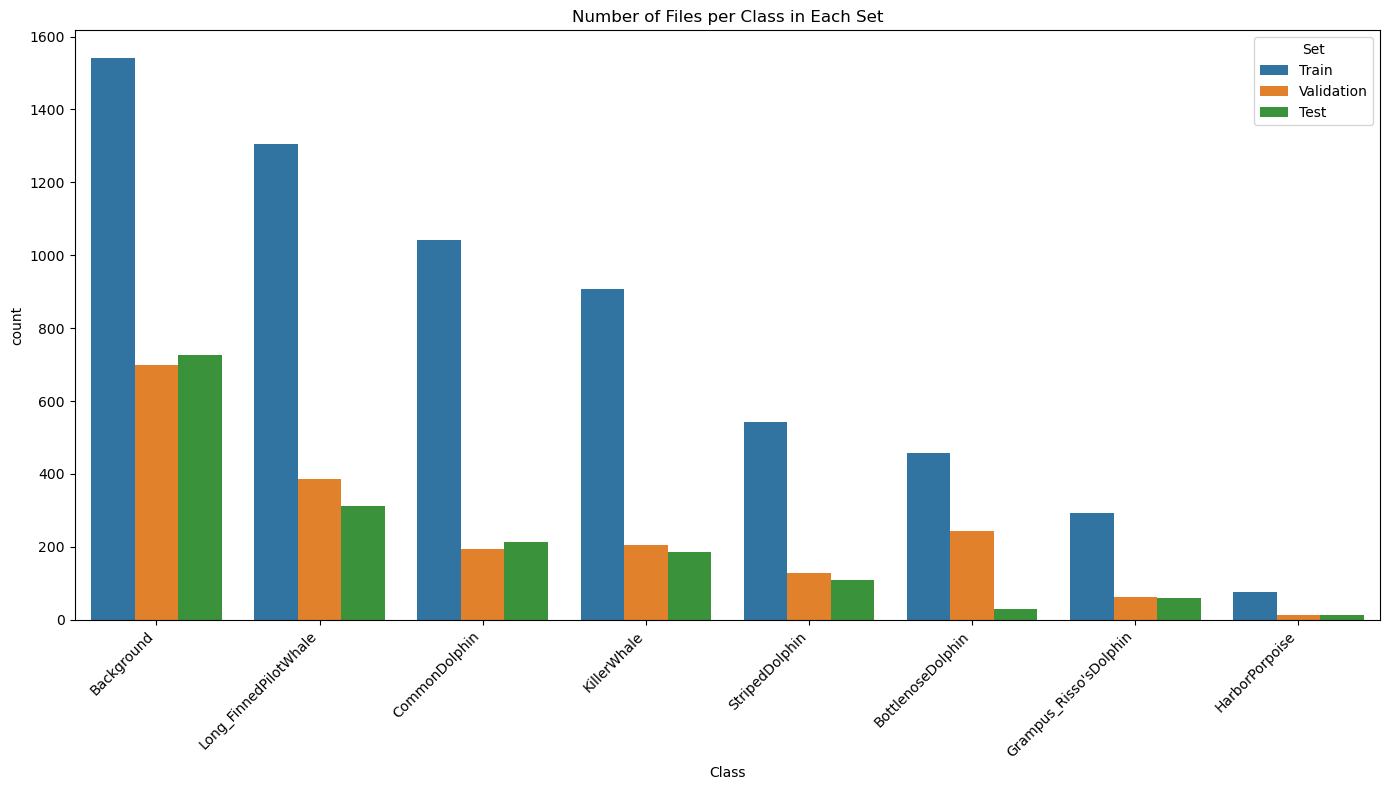

In [70]:
import seaborn as sns

# Plot count per class, each subset is a bar for each class (train, val and test)
class_counts = df['Class'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='Class', hue='Set', order=class_counts.index)
plt.title('Number of Files per Class in Each Set')
plt.xticks(rotation=45, ha='right', fontsize=10)  # Adjust fontsize and alignment
plt.legend(title='Set')
plt.tight_layout()  # Adjust layout to make room for labels
plt.show()

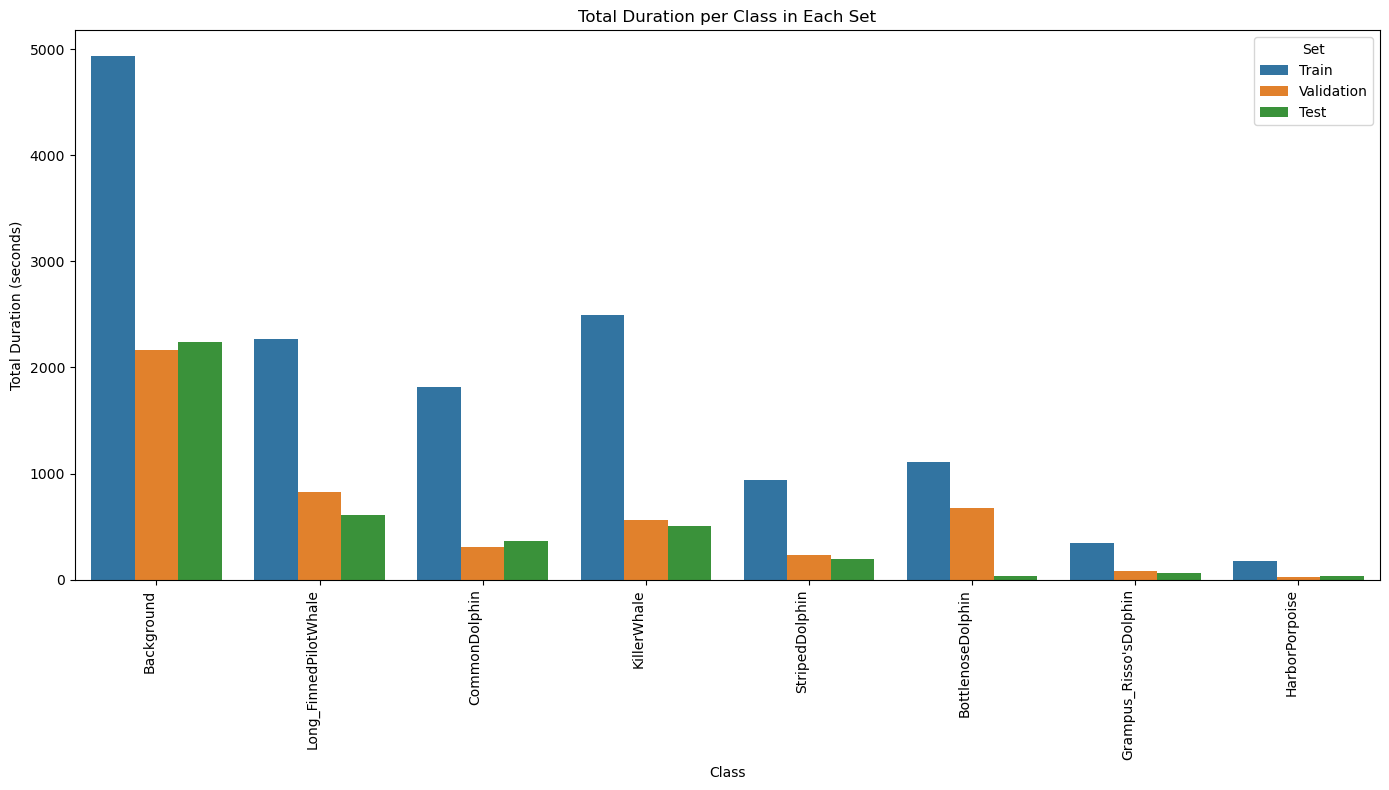

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_train, df_val, df_test are already defined and have a 'Duration' column

# Add 'Set' column
df_train['Set'] = 'Train'
df_val['Set'] = 'Validation'
df_test['Set'] = 'Test'

# Concatenate all dataframes
df = pd.concat([df_train, df_val, df_test])

# Aggregate total duration per class and subset
duration_df = df.groupby(['Class', 'Set'])['Duration'].sum().reset_index()

# Ensure the order of the bars is Train, Validation, and Test
duration_df['Set'] = pd.Categorical(duration_df['Set'], categories=['Train', 'Validation', 'Test'], ordered=True)

# Plot the total duration per class and subset
plt.figure(figsize=(14, 8))
sns.barplot(data=duration_df, x='Class', y='Duration', hue='Set', order=class_counts.index)
plt.title('Total Duration per Class in Each Set')
plt.xticks(rotation=90, ha='right', fontsize=10)  # Adjust fontsize and alignment
plt.ylabel('Total Duration (seconds)')
plt.legend(title='Set')
plt.tight_layout()  # Adjust layout to make room for labels
plt.show()

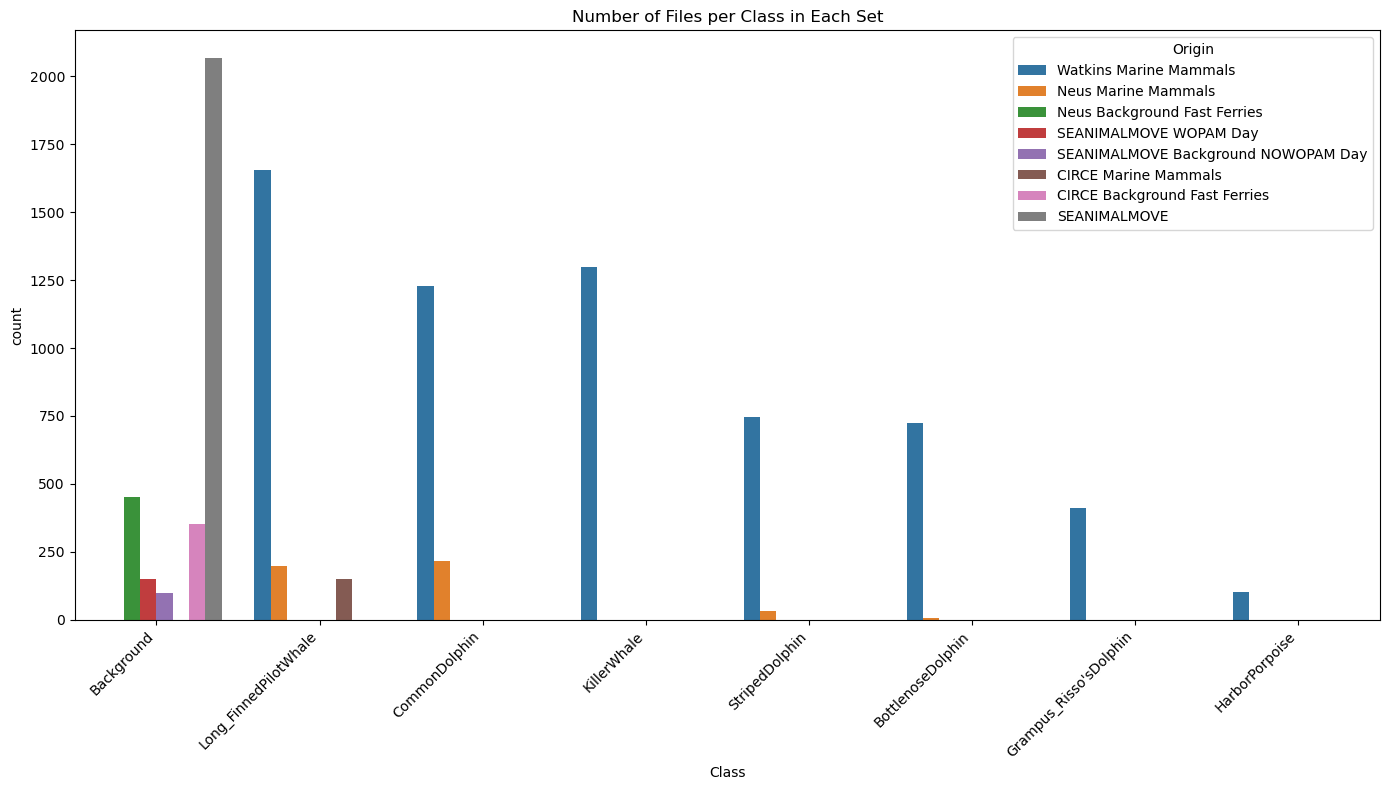

In [72]:
# Create a plot to see the proportion of each Origin in each class and subset
df_reset = df.reset_index(drop=True)  # Reset index to avoid duplicate labels
plt.figure(figsize=(14, 8))
sns.countplot(data=df_reset, x='Class', hue='Origin', order=class_counts.index)
plt.title('Number of Files per Class in Each Set')
plt.xticks(rotation=45, ha='right', fontsize=10)  # Adjust fontsize and alignment
plt.legend(title='Origin')
plt.tight_layout()  # Adjust layout to make room for labels
plt.show()

In [73]:
# reset index in all sets
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [74]:
# All classes that are not Background, make them Whistle
df_train.loc[~df_train['Class'].isin(['Background']), 'Class'] = 'Whistle'
df_val.loc[~df_val['Class'].isin(['Background']), 'Class'] = 'Whistle'
df_test.loc[~df_test['Class'].isin(['Background']), 'Class'] = 'Whistle'
df.loc[~df['Class'].isin(['Background']), 'Class'] = 'Whistle'
df_wopam_day.loc[~df_wopam_day['Class'].isin(['Background']), 'Class'] = 'Whistle'

In [75]:
# take classes and classes_mapping from df_wmm
CLASSES = df['Class'].unique()
CLASSES.sort()
# Add Background as first class
# CLASSES = np.insert(CLASSES, 0, 'Background')
CLASSES_MAPPING = {CLASSES[i]: i for i in range(len(CLASSES))}
REVERSE_CLASSES_MAPPING = {v: k for k, v in CLASSES_MAPPING.items()}
CLASSES, CLASSES_MAPPING, REVERSE_CLASSES_MAPPING

(array(['Background', 'Whistle'], dtype=object),
 {'Background': 0, 'Whistle': 1},
 {0: 'Background', 1: 'Whistle'})

In [76]:
# rename column SegmentPath as File
df_train = df_train.rename(columns={'SegmentPath': 'File'})
df_val = df_val.rename(columns={'SegmentPath': 'File'})
df_test = df_test.rename(columns={'SegmentPath': 'File'})
df_background = df_background.rename(columns={'SegmentPath': 'File'})
df_wopam_day = df_wopam_day.rename(columns={'SegmentPath': 'File'})

In [77]:
# For those classes with less than 1000 samples, upsample until they have 1000 samples
def up_sampling(dataframe, num_samples=100):

    # Classes and their files
    classes = dataframe['Class'].unique()

    for class_df in classes:
        # Get the number of samples in the class
        num_samples_class = len(dataframe[dataframe['Class'] == class_df])
        
        # If the number of samples is less than 1000
        if num_samples_class < num_samples:
            # Calculate the number of samples to add
            num_samples_to_add = num_samples - num_samples_class
            
            # Get the files to add
            files_to_add = dataframe[dataframe['Class'] == class_df].sample(num_samples_to_add, replace=True)
            
            # Concatenate the files to the dataframe
            dataframe = pd.concat([dataframe, files_to_add])
    
    return dataframe

In [78]:
# If SegmentPath contains Human_diver extract in a df
df_human_diver = df_train[df_train['FilePath'].str.contains('Human_diver')]
df_train = df_train[~df_train['FilePath'].str.contains('Human_diver')]
# upsample df_human_diver
df_human_diver_upsampled = up_sampling(df_human_diver, num_samples=500)
df_train = pd.concat([df_train, df_human_diver])

df_human_diver_val = df_val[df_val['FilePath'].str.contains('Human_diver')]
df_val = df_val[~df_val['FilePath'].str.contains('Human_diver')]
# upsample df_human_diver_val
df_human_diver_val = up_sampling(df_human_diver_val, num_samples=100)
df_val = pd.concat([df_val, df_human_diver_val])

In [79]:
df_train_upsampled = up_sampling(df_train, num_samples=4500)
df_val_upsampled = up_sampling(df_val, num_samples=1500)
df_train = pd.concat([df_train, df_human_diver])

In [80]:
# concat human diver
df_train_upsampled = pd.concat([df_train_upsampled, df_human_diver_upsampled])
df_val_upsampled = pd.concat([df_val_upsampled, df_human_diver_val])

In [81]:
df_upsampled = pd.concat([df_train_upsampled, df_val_upsampled, df_test])

In [82]:
# Add a column to indicate if the file is original or upsampled
df_upsampled['Type'] = 'Original'
df_upsampled.loc[df_upsampled.duplicated(subset=['File', 'Class', 'Set'], keep=False), 'Type'] = 'Upsampled'

# put first duplicated as Original
df_upsampled.loc[df_upsampled.duplicated(subset=['File', 'Class', 'Set'], keep='first'), 'Type'] = 'Original'

df_original = df_upsampled[df_upsampled['Type'] == 'Original']

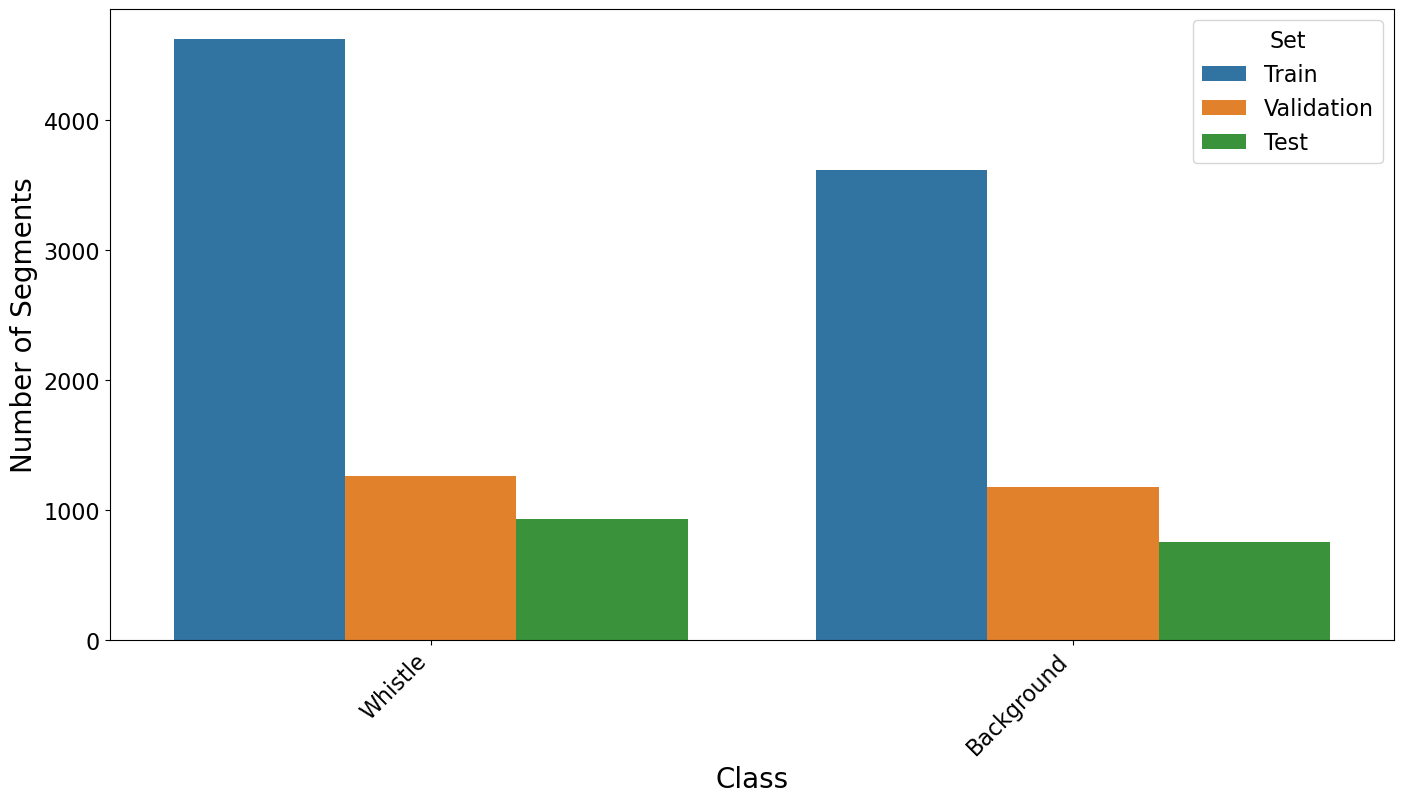

In [83]:
# Plot count df_upsampled class, each subset is a bar for each class (train, val and test)
class_counts = df_original['Class'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.countplot(data=df_original, x='Class', hue='Set', order=class_counts.index)
# plt.title('Number of Files per Class in Each Set')
plt.xticks(rotation=45, ha='right', fontsize=16)  # Adjust fontsize and alignment
plt.yticks(fontsize=16)
plt.legend(title='Set', fontsize=16, title_fontsize=16)
plt.tight_layout()  # Adjust layout to make room for labels
plt.ylabel('Number of Segments', fontsize=20)
plt.xlabel('Class', fontsize=20)

# save as pdf
plt.savefig('../../Figures/BinaryDistribution.pdf')

plt.show()

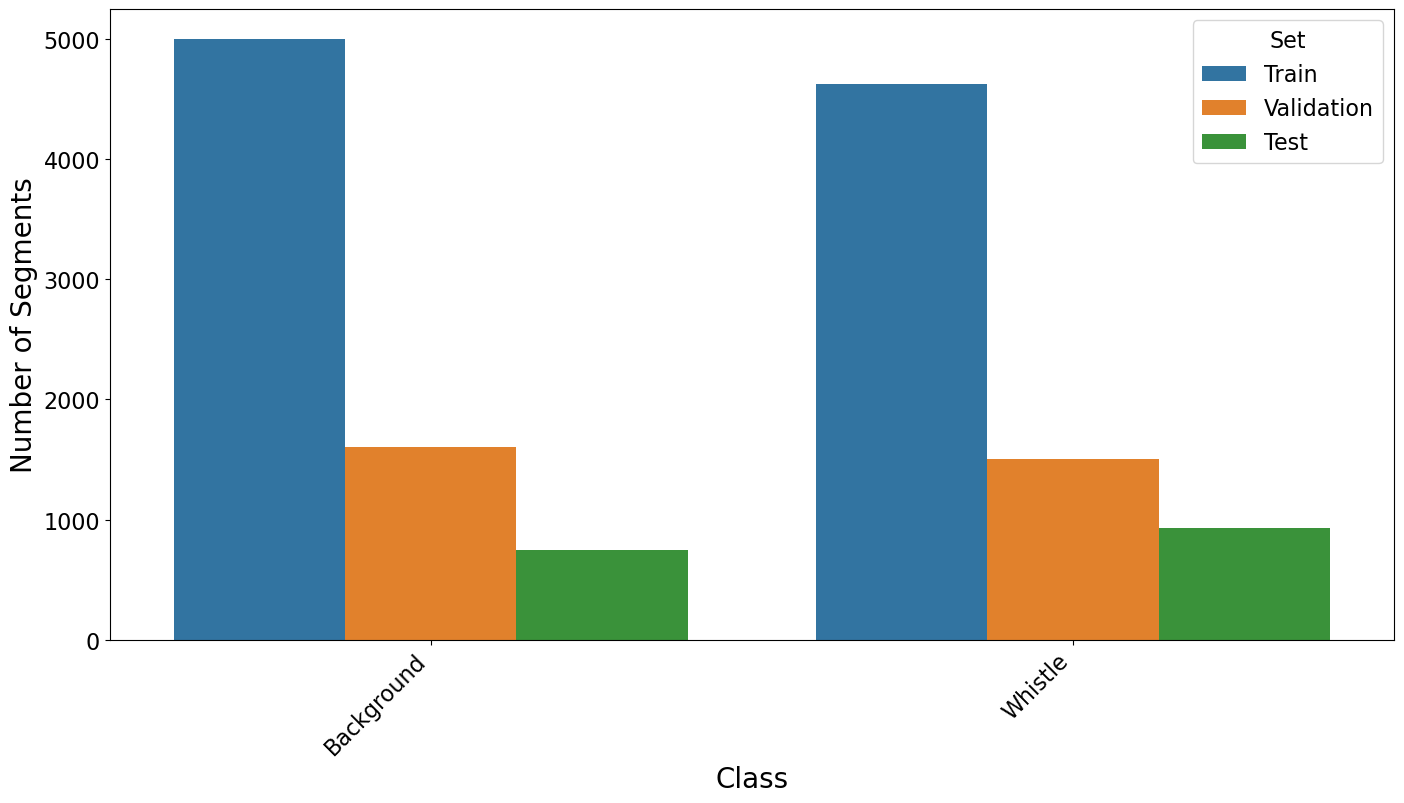

In [84]:
# Add a column to indicate if the file is original or upsampled
df_upsampled['Type'] = 'Original'
df_upsampled.loc[df_upsampled.duplicated(subset=['File', 'Class', 'Set'], keep=False), 'Type'] = 'Upsampled'

# put first duplicated as Original
df_upsampled.loc[df_upsampled.duplicated(subset=['File', 'Class', 'Set'], keep='first'), 'Type'] = 'Original'

# Plot count df_upsampled class, each subset is a bar for each class (train, val and test)
class_counts = df_upsampled['Class'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.countplot(data=df_upsampled, x='Class', hue='Set', order=class_counts.index)
# plt.title('Number of Files per Class in Each Set')
plt.xticks(rotation=45, ha='right', fontsize=16)  # Adjust fontsize and alignment
plt.yticks(fontsize=16)
plt.legend(title='Set', fontsize=16, title_fontsize=16)
plt.tight_layout()  # Adjust layout to make room for labels
plt.ylabel('Number of Segments', fontsize=20)
plt.xlabel('Class', fontsize=20)

# save as pdf
plt.savefig('../../Figures/BinaryDistribution.pdf')

plt.show()

In [85]:
df_upsampled

,FilePath,File,Class,Duration,Origin,Subset,OriginalClass,Set,Type
0,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,1.073438,Watkins Marine Mammals,train,Grampus_Risso'sDolphin,Train,Original
1,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,1.877983,Watkins Marine Mammals,train,Long_FinnedPilotWhale,Train,Original
2,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,1.417969,Watkins Marine Mammals,train,CommonDolphin,Train,Original
3,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,2.582300,Watkins Marine Mammals,train,CommonDolphin,Train,Original
4,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,1.158500,Watkins Marine Mammals,train,CommonDolphin,Train,Original
...,...,...,...,...,...,...,...,...,...
1674,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,2.049863,Watkins Marine Mammals,test,KillerWhale,Test,Original
1675,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,2.035900,Watkins Marine Mammals,test,KillerWhale,Test,Original
1676,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,2.032750,Watkins Marine Mammals,test,KillerWhale,Test,Original
1677,../../Dataset/Audios/Watkins Marine Mammals/Fu...,../../Dataset/Audios/Watkins Marine Mammals/Se...,Whistle,2.028000,Watkins Marine Mammals,test,KillerWhale,Test,Original


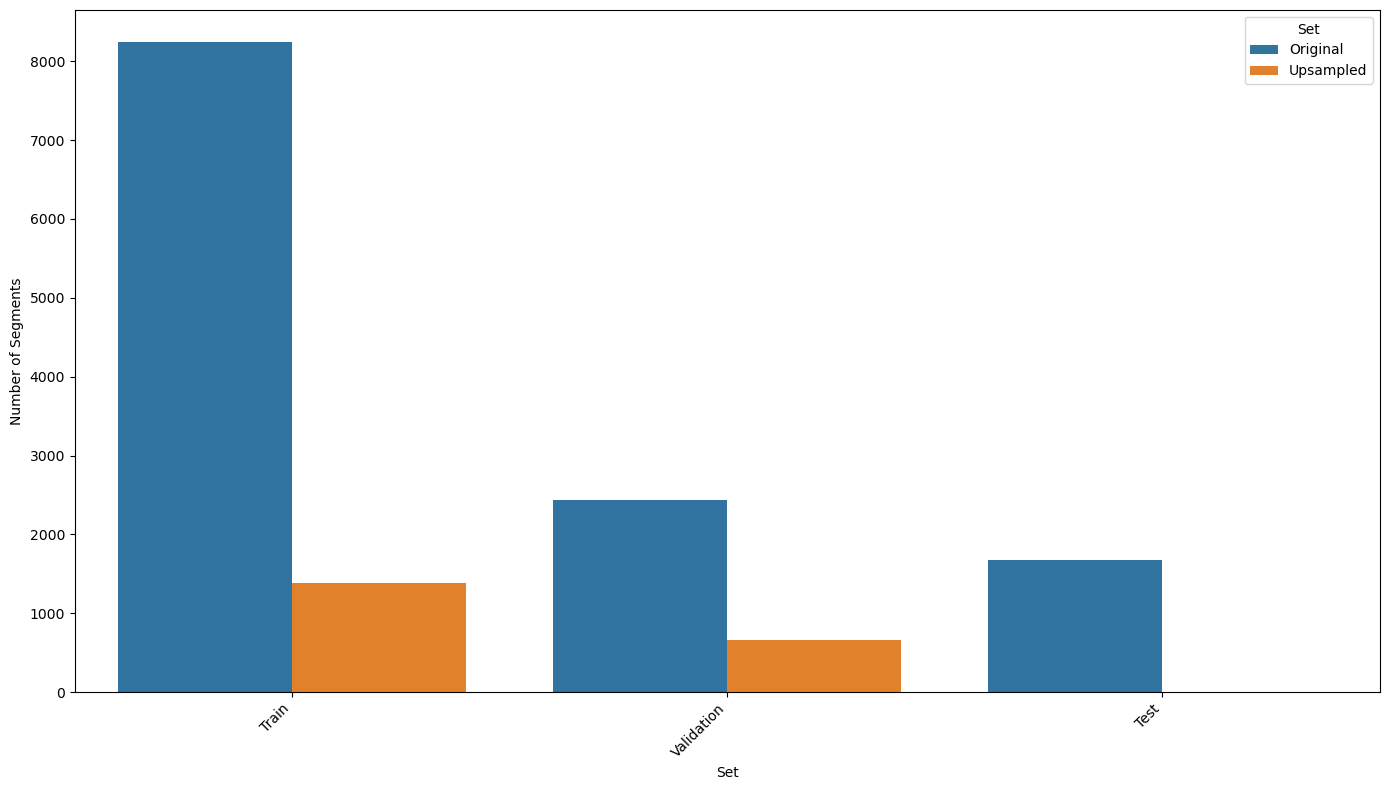

In [86]:
# Add a column to indicate if the file is original or upsampled
df_upsampled['Type'] = 'Original'
df_upsampled.loc[df_upsampled.duplicated(subset=['File', 'Class', 'Set'], keep=False), 'Type'] = 'Upsampled'

# put first duplicated as Original
df_upsampled.loc[df_upsampled.duplicated(subset=['File', 'Class', 'Set'], keep='first'), 'Type'] = 'Original'

# Plot count df_upsampled class, each subset is a bar for each class (train, val and test)
class_counts = df_upsampled['Set'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.countplot(data=df_upsampled, x='Set', hue='Type', order=class_counts.index)
# plt.title('Number of Files per Class in Each Set')
plt.xticks(rotation=45, ha='right', fontsize=10)  # Adjust fontsize and alignment
plt.legend(title='Set')
plt.tight_layout()  # Adjust layout to make room for labels
plt.ylabel('Number of Segments')
plt.show()

In [39]:
# # delete column subset
# df_train = df_train.drop(columns=['Subset'])
# df_val = df_val.drop(columns=['Subset'])
# df_test = df_test.drop(columns=['Subset'])

In [40]:
# # save train, test and validation in CSVs/Datasets
# df_train.to_csv('../../Dataset/CSVs/FullTrain.csv', index=False)
# df_val.to_csv('../../Dataset/CSVs/FullValidation.csv', index=False)
# df_test.to_csv('../../Dataset/CSVs/FullTest.csv', index=False)

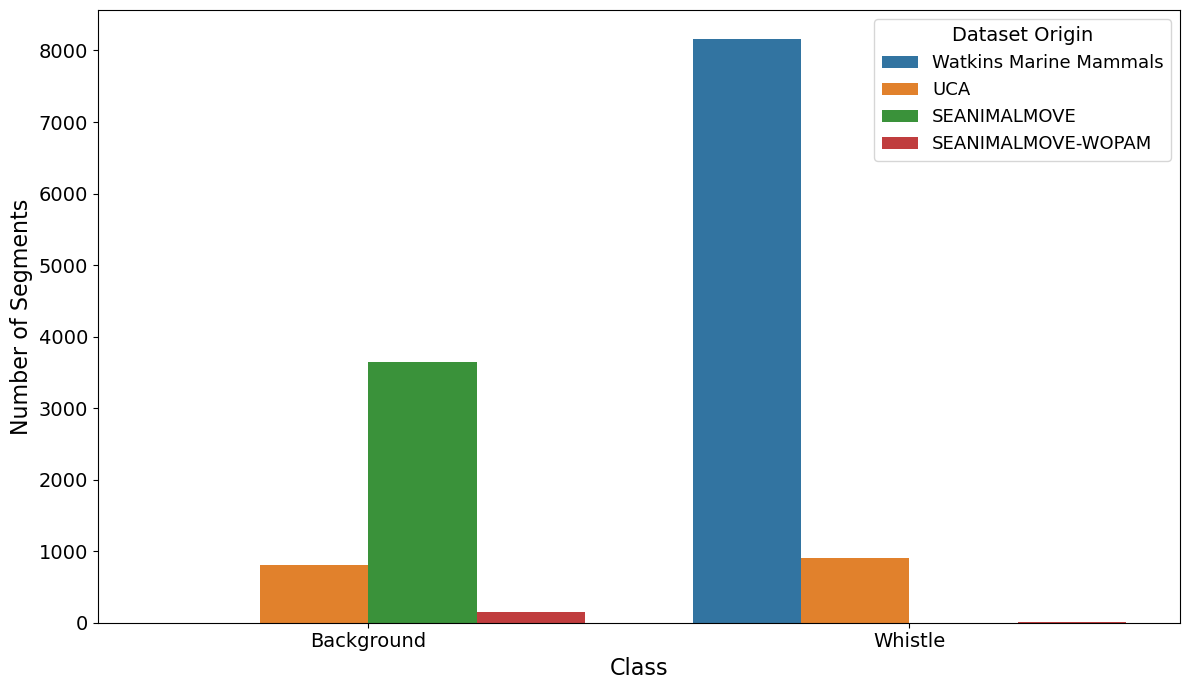

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Load final preprocessed dataset (after binarization & upsampling decisions)
# df = pd.read_csv('../../Dataset/CSVs/Datasets/Dataset.csv')

# # Merge classes into binary labels
# df.loc[df['Class'].isin([
#     'Ferry_FastFerry', 'Motor_boat', 'Cargo', 'Human_diver'
# ]), 'Class'] = 'Background'

# df.loc[df['Class'] != 'Background', 'Class'] = 'Whistle'

# # Harmonize origin labels
# origin_mapping = {
#     'Neus Background Fast Ferries': 'Laboratory of Acoustic Engineering of the University of Cádiz',
#     'Neus Marine Mammals': 'Laboratory of Acoustic Engineering of the University of Cádiz',
#     'CIRCE Marine Mammals': 'Laboratory of Acoustic Engineering of the University of Cádiz',
#     'CIRCE Background Fast Ferries': 'Laboratory of Acoustic Engineering of the University of Cádiz',
#     'SEANIMALMOVE Background NOWOPAM Day': 'SEANIMALMOVE',
#     'SEANIMALMOVE WOPAM Day': 'SEANIMALMOVE-WOPAM'
# }
# df['Origin'] = df['Origin'].replace(origin_mapping)

# # Plot final counts
# plt.figure(figsize=(12, 7))
# sns.countplot(
#     data=df,
#     x='Class',
#     hue='Origin',
#     order=['Background', 'Whistle']
# )

# plt.ylabel('Number of Segments', fontsize=16)
# plt.xlabel('Class', fontsize=16)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.legend(title='Dataset Origin', fontsize=13, title_fontsize=14)
# plt.tight_layout()

# plt.savefig('../../Figures/FinalDistribution_ByOrigin.pdf')
# plt.show()

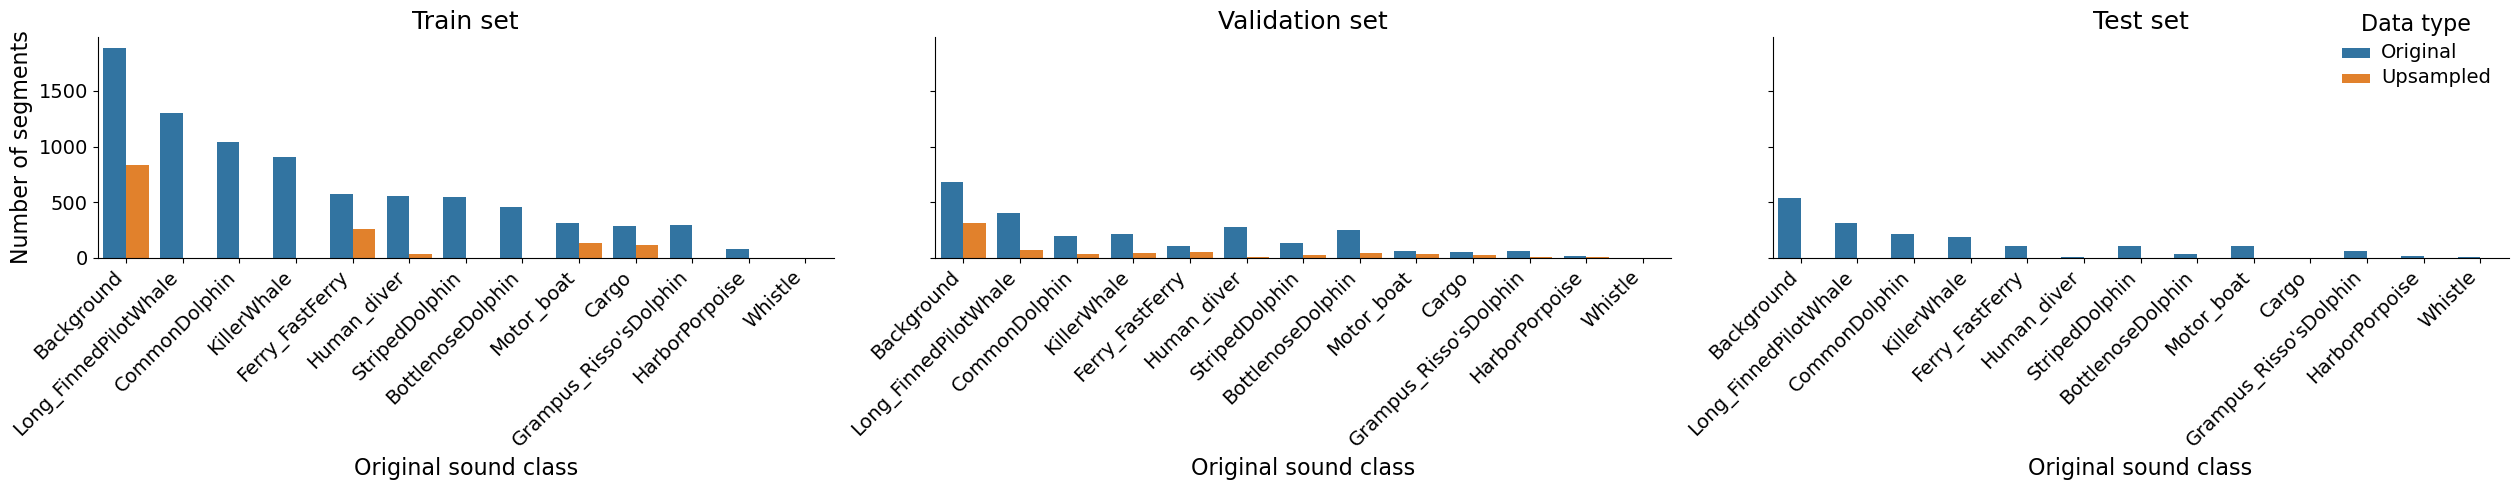

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df_upsampled already loaded
# Ensure consistent origin naming (optional, if already harmonized)
df = df_upsampled.copy()

# Order species by total number of samples (after upsampling)
class_order = (
    df.groupby('OriginalClass')
      .size()
      .sort_values(ascending=False)
      .index
)

# Create the plot
g = sns.catplot(
    data=df,
    x='OriginalClass',
    hue='Type',              # Original vs Upsampled
    col='Set',               # Train / Validation / Test
    kind='count',
    order=class_order,
    col_order=['Train', 'Validation', 'Test'],
    height=5,
    aspect=1.6,
    sharey=True
)

# Formatting with bigger font sizes
g.set_axis_labels("Original sound class", "Number of segments", fontsize=16)
g.set_titles("{col_name} set", size=18)
g.set_xticklabels(rotation=45, ha='right', fontsize=14)

# Increase y-axis tick label size
for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=14)

# Legend formatting with bigger font
g._legend.set_title('Data type')
for text in g._legend.texts:
    text.set_fontsize(14)
g._legend.get_title().set_fontsize(16)

# Move legend to top right
g._legend.set_bbox_to_anchor((0.99, 0.88))

plt.tight_layout()
plt.savefig('../../Figures/AppendixC_FinalDistribution_BySpecies_Original_vs_Upsampled.pdf')
plt.show()

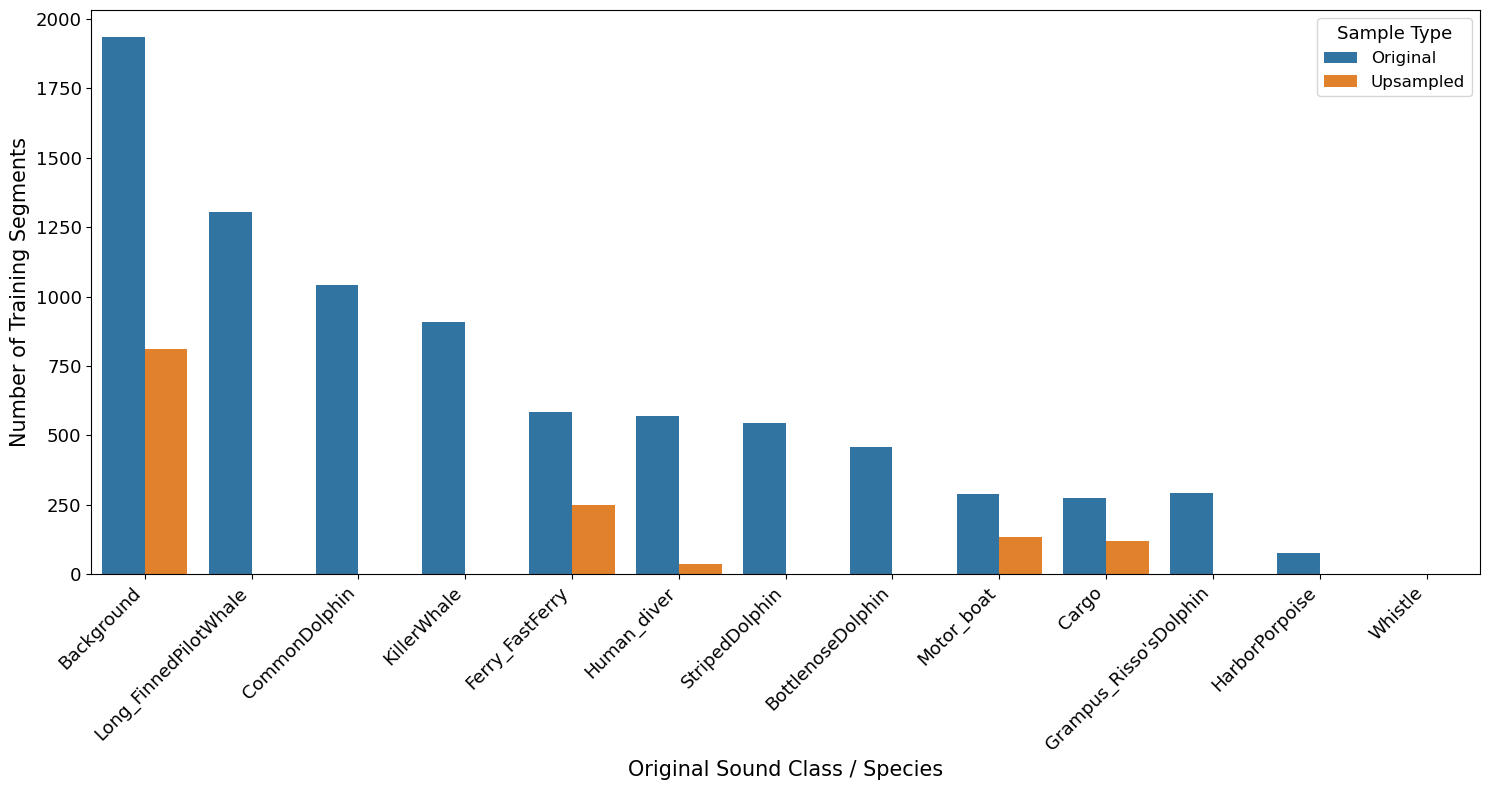

In [44]:
plt.figure(figsize=(15, 8))

sns.countplot(
    data=df[df['Set'] == 'Train'],   # training data only
    x='OriginalClass',
    hue='Type',
    order=class_order
)

plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Original Sound Class / Species', fontsize=15)
plt.ylabel('Number of Training Segments', fontsize=15)
plt.legend(title='Sample Type', fontsize=12, title_fontsize=13)
plt.tight_layout()

plt.savefig('../../Figures/AppendixC_TrainingDistribution_BySpecies_Original_vs_Upsampled.pdf')
plt.show()

In [ ]:
g = sns.catplot(
    data=df,
    x='Class',
    hue='Type',
    col='Origin',
    kind='count',
    col_wrap=2,
    height=4,
    aspect=1.5,
    order=class_order
)

g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels("Sound Class / Species", "Number of Segments")
g._legend.set_title("Sample Type")

plt.tight_layout()
plt.savefig('../../Figures/ClassDistribution_ByOrigin_Original_vs_Upsampled.pdf')
plt.show()
